# RFE Expanded


This notebook extends `rfe.ipynb` by applying the feature subset selected by RFE to all baseline models for comparison.


In [1]:
import sys
from pathlib import Path

_here = Path().resolve()
REPO_ROOT = _here
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "src" / "stroke_data.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise FileNotFoundError("Could not find src/stroke_data.py (open this project from the repo folder).")

sys.path.insert(0, str(REPO_ROOT / "src"))


## Imports


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.svm import SVC
from xgboost import XGBClassifier

from stroke_data import get_stroke_data_for_cv


## Data And Configuration


In [3]:
CSV = "data/knn-standardize-distance.csv"
OUT = "src/feature_selection/rfe_selection.csv"
N_FEATURES_TO_SELECT = 8
RFE_STEP = 1

csv_path = REPO_ROOT / CSV
df = pd.read_csv(csv_path)
feature_names = [c for c in df.columns if c not in ("id", "stroke")]

X_train, X_test, y_train, y_test = get_stroke_data_for_cv(str(csv_path))
len(feature_names), X_train.shape


(10, (4088, 10))

## Run RFE


In [4]:
base_estimator = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=2000,
    solver="lbfgs",
)

selector = RFE(
    estimator=base_estimator,
    n_features_to_select=N_FEATURES_TO_SELECT,
    step=RFE_STEP,
)
selector.fit(X_train, y_train)

rfe_df = pd.DataFrame({
    "feature": feature_names,
    "selected": selector.support_,
    "ranking": selector.ranking_,
}).sort_values(["selected", "ranking", "feature"], ascending=[False, True, True])

rfe_df


,feature,selected,ranking
6,Residence_type,True,1
1,age,True,1
7,avg_glucose_level,True,1
8,bmi,True,1
4,ever_married,True,1
0,gender,True,1
3,heart_disease,True,1
2,hypertension,True,1
5,work_type,False,2
9,smoking_status,False,3


## Save RFE Selection


In [5]:
out_path = REPO_ROOT / OUT
out_path.parent.mkdir(parents=True, exist_ok=True)
rfe_df.to_csv(out_path, index=False)
out_path


PosixPath('/Users/brad/gitClones/Stroke-Prediction-ML/src/feature_selection/rfe_selection.csv')

## Build Selected Subset


In [6]:
mask = selector.support_
selected_features = rfe_df.loc[rfe_df["selected"], "feature"].tolist()

X_train_subset = X_train[:, mask]
X_test_subset = X_test[:, mask]

selected_features


['Residence_type',
 'age',
 'avg_glucose_level',
 'bmi',
 'ever_married',
 'gender',
 'heart_disease',
 'hypertension']

## Baseline Models


In [7]:
def build_baseline_models():
    return {
        "lr": LogisticRegression(random_state=42, C=0.1, class_weight="balanced", solver="newton-cg"),
        "svm": SVC(C=10.0, class_weight="balanced", gamma=0.01, kernel="rbf"),
        "rf": RandomForestClassifier(
            bootstrap=True,
            class_weight="balanced_subsample",
            max_depth=15,
            max_features=None,
            max_leaf_nodes=15,
            n_estimators=20,
            random_state=42,
        ),
        "xgb": XGBClassifier(
            eta=1,
            gamma=1,
            reg_lambda=0.5,
            max_depth=15,
            objective="binary:logistic",
            subsample=1,
            scale_pos_weight=19,
            eval_metric="logloss",
        ),
    }


def metric_row(model_name, subset_name, Xtr, Xte):
    model = clone(build_baseline_models()[model_name])
    model.fit(Xtr, y_train)
    pred = model.predict(Xte)
    return {
        "model": model_name,
        "subset": subset_name,
        "n_features": Xtr.shape[1],
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, pos_label=1),
        "precision": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, pred, pos_label=1, zero_division=0),
    }


## Evaluate Full vs RFE Subset Across All Baselines


In [8]:
subset_data = {
    "full": (X_train, X_test),
    "rfe-subset": (X_train_subset, X_test_subset),
}

rows = []
for model_name in build_baseline_models():
    for subset_name, (Xtr, Xte) in subset_data.items():
        rows.append(metric_row(model_name, subset_name, Xtr, Xte))

eval_df = pd.DataFrame(rows).sort_values(["model", "n_features"]).reset_index(drop=True)
eval_df.style.format({
    "accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "precision": "{:.4f}",
    "recall": "{:.4f}",
}).hide(axis="index")


model,subset,n_features,accuracy,f1,precision,recall
lr,rfe-subset,8,0.7495,0.2381,0.1399,0.8000
lr,full,10,0.7466,0.2360,0.1384,0.8000
rf,rfe-subset,8,0.7730,0.2564,0.1527,0.8000
rf,full,10,0.7789,0.2614,0.1562,0.8000
svm,rfe-subset,8,0.7153,0.2156,0.1246,0.8000
svm,full,10,0.7339,0.2229,0.1300,0.7800
xgb,rfe-subset,8,0.9266,0.2574,0.2549,0.2600
xgb,full,10,0.9061,0.1429,0.1290,0.1600


## Pivot View For Easier Comparison


In [9]:
eval_df.pivot(index="model", columns="subset", values=["accuracy", "f1", "precision", "recall"]).round(4)


accuracy                 f1            precision            recall  \
subset     full rfe-subset    full rfe-subset      full rfe-subset   full   
model                                                                       
lr       0.7466     0.7495  0.2360     0.2381    0.1384     0.1399   0.80   
rf       0.7789     0.7730  0.2614     0.2564    0.1562     0.1527   0.80   
svm      0.7339     0.7153  0.2229     0.2156    0.1300     0.1246   0.78   
xgb      0.9061     0.9266  0.1429     0.2574    0.1290     0.2549   0.16   

                   
subset rfe-subset  
model              
lr           0.80  
rf           0.80  
svm          0.80  
xgb          0.26

## Optional Export


In [10]:
expanded_out = REPO_ROOT / "src/feature_selection/rfe_expand_results.csv"
eval_df.to_csv(expanded_out, index=False)
expanded_out


PosixPath('/Users/brad/gitClones/Stroke-Prediction-ML/src/feature_selection/rfe_expand_results.csv')

## ADDED FOR PRESENTATION: F1 Comparison Chart

This section was added for presentation slides. It keeps the existing notebook results and creates a cleaner grouped bar chart for slide use.


,model,subset,n_features,f1
0,lr,full,10,0.235988
1,lr,rfe-subset,8,0.238095
2,rf,full,10,0.261438
3,rf,rfe-subset,8,0.256410
4,svm,full,10,0.222857
5,svm,rfe-subset,8,0.215633
6,xgb,full,10,0.142857
7,xgb,rfe-subset,8,0.257426


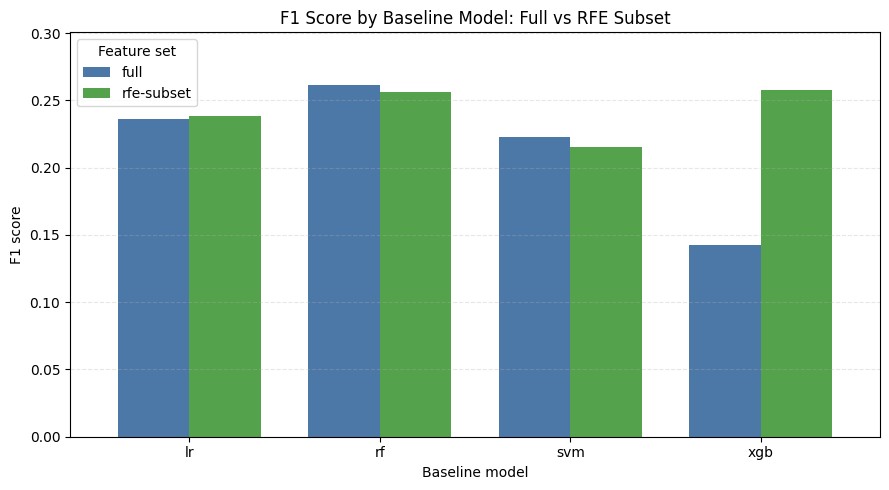

In [11]:
# ADDED FOR PRESENTATION: keep only the full-feature result and the RFE subset result
# so we can make one simple grouped bar chart for the slide.
presentation_df = eval_df[eval_df["subset"].isin(["full", "rfe-subset"])].copy()
presentation_df["subset"] = pd.Categorical(
    presentation_df["subset"],
    categories=["full", "rfe-subset"],
    ordered=True,
)
presentation_df = presentation_df.sort_values(["model", "subset"]).reset_index(drop=True)

# ADDED FOR PRESENTATION: plot model-wise F1 comparison.
# We use F1 because it better reflects minority-class performance than accuracy.
pivot_f1 = presentation_df.pivot(index="model", columns="subset", values="f1")
ax = pivot_f1.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4C78A8", "#54A24B"],
    width=0.75,
)
ax.set_title("F1 Score by Baseline Model: Full vs RFE Subset")
ax.set_xlabel("Baseline model")
ax.set_ylabel("F1 score")
ax.set_ylim(0, max(0.05, float(pivot_f1.max().max()) * 1.15))
ax.legend(title="Feature set")
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()

# ADDED FOR PRESENTATION: show the exact F1 values for quick slide reference.
presentation_df[["model", "subset", "n_features", "f1"]].sort_values(["model", "subset"])
